# Teen Smartphone Usage and Addiction Impact Dataset - Machine Learning 2 Regression project


## About the Dataset

This dataset, sourced from Kaggle, focuses on understanding **smartphone usage patterns among teenagers** and the impact of excessive phone use on their **academic performance, mental health, and daily lifestyle**. With the rapid increase in smartphone dependency among adolescents, it has become important to study how usage habits influence well-being and performance.

The dataset captures multiple aspects of teenage behavior, including **addiction levels, time distribution across activities, sleep patterns, social interactions, and mental health indicators**. From our perspective, we aim to build regression models to examine which factors have the greatest impact on smartphone addiction levels.

---

## Column Descriptions

### Demographic Information
- **ID**: Unique identifier for each student  
- **Name**: Name of the student  
- **Age**: Age of the teenager  
- **Gender**: Gender of the student  
- **Location**: Geographic location  
- **School_Grade**: Current academic or level  

### Smartphone Usage & Time Distribution
- **Daily_Usage_Hours**: Average smartphone usage per day (hours)  
- **Weekend_Usage_Hours**: Average smartphone usage on weekends  
- **Screen_Time_Before_Bed**: Screen time before going to sleep  
- **Phone_Checks_Per_Day**: Number of times the phone is checked daily  
- **Apps_Used_Daily**: Number of apps used per day  

### Activity-Based Usage
- **Time_on_Social_Media**: Hours spent on social media platforms  
- **Time_on_Gaming**: Hours spent on mobile gaming  
- **Time_on_Education**: Hours spent on educational activities  
- **Phone_Usage_Purpose**: Primary purpose of smartphone usage  

### Health & Lifestyle Indicators
- **Sleep_Hours**: Average hours of sleep per day  
- **Exercise_Hours**: Time spent on physical exercise  
- **Anxiety_Level**: Indicator of anxiety level  
- **Depression_Level**: Indicator of depression level  
- **Self_Esteem**: Self-esteem score  

### Social & Family Factors
- **Social_Interactions**: Level of in-person social interaction  
- **Family_Communication**: Quality or frequency of communication with family  
- **Parental_Control**: Level of parental monitoring or restrictions  

### Outcome Variables
- **Academic_Performance**: Indicator of academic performance  
- **Addiction_Level**: Level of smartphone addiction (target variable)

---

## Problem Description

Smartphone use has become an essential part of teenagers’ daily lives, but excessive usage may lead to addiction and negatively affect mental health, sleep patterns, social interactions, and academic performance. Smartphone addiction among adolescents is an increasingly important social and psychological issue. The goal of this project is to use regression analysis to identify which behavioral, lifestyle, and psychological factors most strongly influence the level of smartphone addiction. Understanding these relationships can support early intervention and promote healthier smartphone usage habits among teenagers.

---



# Importing neccessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import warnings

warnings.filterwarnings("ignore")

# Section 1: Data Loading and Initial Exploration

In this section, we load the dataset and perform initial exploratory analysis to understand the data structure, identify potential issues, and assess data quality.

In [2]:
# Load the teen phone addiction dataset from CSV file
df = pd.read_csv("data/teen_phone_addiction_dataset.csv")

In [3]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (3000, 25)

First few rows:


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [4]:
# Descriptive statistics of the dataset
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [5]:
# Check for missing values in the dataset
df.duplicated().sum()

np.int64(0)

No duplicates found

In [6]:
# Check for missing values in the dataset
df.isnull().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

Now as we have don't have missing values, we are going to remove unnecessary columns and test-train split.

# Section 2: Data Cleaning and Preprocessing

Now we'll remove unnecessary columns and split the data into training and test sets. Then, we'll apply one-hot encoding to categorical variables.

## Step 1: Remove non-informative columns

Columns like 'Name' and 'ID' don't contribute to predictions since they are just identifiers. We'll drop them to reduce noise.

In [7]:
df = df.drop(columns=["Name", "ID"])

## Step 2: Train-Test Split

We split the data into 80% training and 20% testing sets. Using random_state=123 ensures reproducibility.

In [8]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=123)

In [9]:
print("\nTRAIN:")
display(df_train.head())
print("SHAPE:",df_train.shape)

print("\nTEST:")
display(df_test.head())
print("SHAPE:",df_test.shape)


TRAIN:


,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
497,13,Female,South Timothymouth,10th,4.0,10.0,56,2,1.9,5,...,0.2,83,6,2.3,0.7,1.3,Other,5,5.5,4.9
21,16,Female,North Scott,12th,2.7,6.3,92,3,1.4,2,...,1.7,112,17,2.1,2.6,0.9,Gaming,10,5.7,9.9
1710,15,Female,Bennettmouth,11th,4.1,5.4,75,3,0.7,1,...,1.0,55,18,1.7,0.3,0.3,Gaming,7,9.5,8.1
2323,14,Other,Alexandraville,11th,3.4,6.4,84,2,0.0,10,...,1.3,38,6,1.8,0.7,1.1,Education,3,5.1,4.7
1516,18,Other,South Robyn,7th,3.7,7.4,54,7,0.2,8,...,0.5,21,19,3.0,0.7,0.3,Education,4,6.1,7.9


SHAPE: (2400, 23)

TEST:


,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
1690,15,Male,North Shawn,11th,7.3,5.0,58,1,0.6,9,...,0.5,36,17,1.8,3.0,1.4,Social Media,7,4.6,10.0
1798,19,Female,Davilaborough,8th,4.4,6.4,76,6,1.2,6,...,1.6,33,7,3.1,2.6,1.5,Other,5,7.2,9.0
417,15,Other,New Jessica,8th,3.8,3.9,73,2,1.8,5,...,0.0,85,6,1.5,1.9,1.3,Other,7,6.5,8.2
1599,13,Other,Connerbury,12th,4.7,6.0,93,4,0.0,10,...,1.1,38,19,3.0,0.2,1.6,Social Media,2,5.8,9.5
1206,19,Other,Perezstad,7th,6.0,6.2,60,3,0.5,10,...,2.1,75,5,2.3,0.0,1.3,Browsing,7,4.2,7.7


SHAPE: (600, 23)


## Step 3: Analyze data types and cardinality

Let's examine the data types and unique values for each column to identify categorical variables that need encoding.

In [10]:
# Check data types and information about the training set
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 497 to 1346
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     2400 non-null   int64  
 1   Gender                  2400 non-null   object 
 2   Location                2400 non-null   object 
 3   School_Grade            2400 non-null   object 
 4   Daily_Usage_Hours       2400 non-null   float64
 5   Sleep_Hours             2400 non-null   float64
 6   Academic_Performance    2400 non-null   int64  
 7   Social_Interactions     2400 non-null   int64  
 8   Exercise_Hours          2400 non-null   float64
 9   Anxiety_Level           2400 non-null   int64  
 10  Depression_Level        2400 non-null   int64  
 11  Self_Esteem             2400 non-null   int64  
 12  Parental_Control        2400 non-null   int64  
 13  Screen_Time_Before_Bed  2400 non-null   float64
 14  Phone_Checks_Per_Day    2400 non-null   int

In [11]:
df_train['School_Grade'].unique()

array(['10th', '12th', '11th', '7th', '8th', '9th'], dtype=object)

In [12]:
df_train['Gender'].unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [13]:
len(df_train['Location'].unique())

2219

In [14]:
#let's remove since we have a lot of different values
df_train = df_train.drop(columns=["Location"])

In [15]:
df_train['Phone_Usage_Purpose'].unique()

array(['Other', 'Gaming', 'Education', 'Browsing', 'Social Media'],
      dtype=object)

Based on the above analysis, we need to apply one-hot encoding to School_Grade, Gender and Phone_Usage_Purpose

# Section 3: Exploratory Data Analysis

This section analyzes relationships between variables, target variable distribution, and statistical significance tests.

In [16]:
# Calculate correlation matrix using Kendall's tau (robust to non-normal distributions)
# Kendall correlation is more reliable than Pearson for non-normally distributed data
corr = df_train.select_dtypes(include=['float64', 'int64']).corr(method="kendall")
corr

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
Age,1.000000,0.037611,0.015523,0.012326,-0.011859,0.003724,-0.002620,0.036727,-0.025578,0.016057,-0.005427,0.003881,-0.006195,-0.003034,-0.012402,-0.005322,0.008829,0.004093,0.024809
Daily_Usage_Hours,0.037611,1.000000,0.002175,0.012978,-0.008229,-0.014464,-0.015086,0.010147,0.002816,-0.010041,0.006826,-0.007616,0.013964,-0.003668,-0.006628,0.004430,-0.004039,0.011303,0.489618
Sleep_Hours,0.015523,0.002175,1.000000,-0.011759,-0.007311,0.007350,0.010241,0.001239,0.018216,0.008070,-0.007282,-0.004897,0.010584,-0.002438,0.011152,-0.006818,-0.020937,-0.004983,-0.165595
Academic_Performance,0.012326,0.012978,-0.011759,1.000000,0.014012,0.009242,0.006392,-0.024699,0.004523,-0.010750,-0.007663,-0.014680,-0.022732,0.020297,-0.023755,0.015450,-0.024262,0.014136,-0.002613
Social_Interactions,-0.011859,-0.008229,-0.007311,0.014012,1.000000,0.007119,-0.008277,0.016666,0.015842,-0.022606,-0.019254,0.008462,-0.015975,-0.000983,0.009027,0.002200,0.003223,-0.030362,-0.002736
Exercise_Hours,0.003724,-0.014464,0.007350,0.009242,0.007119,1.000000,-0.002696,-0.021557,-0.009125,0.017042,0.006226,-0.013827,0.012450,-0.010702,-0.022047,0.007418,0.016774,0.021874,-0.021547
Anxiety_Level,-0.002620,-0.015086,0.010241,0.006392,-0.008277,-0.002696,1.000000,0.009917,0.005354,-0.013115,0.009752,0.020888,0.004081,0.012669,0.003654,0.013137,0.013914,0.000590,0.006750
Depression_Level,0.036727,0.010147,0.001239,-0.024699,0.016666,-0.021557,0.009917,1.000000,-0.010078,0.007671,-0.013375,0.008685,0.014649,-0.000098,-0.001351,-0.023222,-0.001115,-0.012749,0.005226
Self_Esteem,-0.025578,0.002816,0.018216,0.004523,0.015842,-0.009125,0.005354,-0.010078,1.000000,-0.023642,-0.005281,-0.004401,-0.023946,-0.000719,-0.018113,-0.019856,-0.012196,-0.029448,-0.018254
Parental_Control,0.016057,-0.010041,0.008070,-0.010750,-0.022606,0.017042,-0.013115,0.007671,-0.023642,1.000000,-0.023368,0.018156,0.007528,-0.006362,-0.008931,0.020005,-0.012061,-0.000556,-0.011042


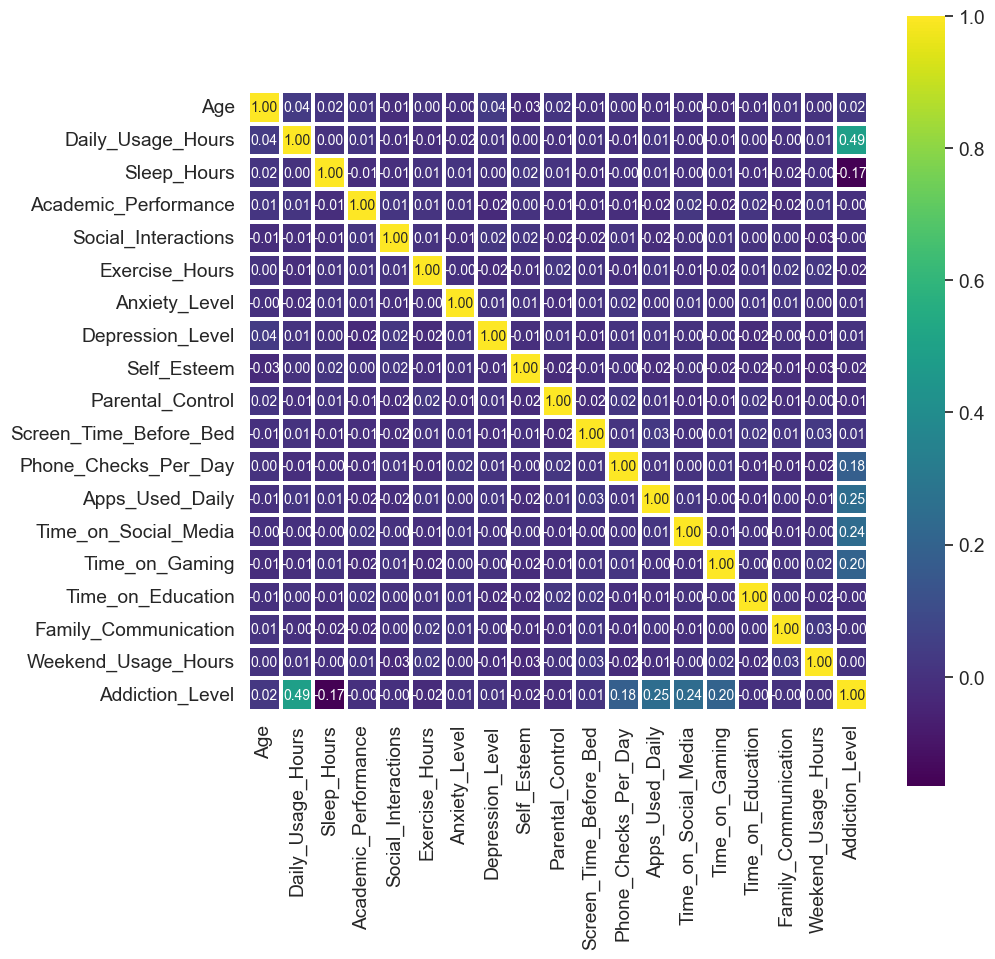

In [17]:
# Visualize correlation matrix as heatmap
plt.figure(figsize=(10,10))
sns.set(font_scale=1.25)
sns.heatmap(corr, linewidths=1.5, annot=True, square=True, fmt=".2f", annot_kws={"size": 10}, cmap="viridis")
plt.show()

- < 0.2 – no linear correlation
- 0.2 – 0.4 – low linear correlation
- 0.4 -0.7 – mid linear correlation
- 0.7 – 0.9 – strong linear correlation
- \> 0.9 – very strong linear correlation

Correlation analysis shows that addiction level is most strongly associated with usage-intensity features, especially Daily_Usage_Hours, as well as Apps_Used_Daily, Time_on_Social_Media, Phone_Checks_Per_Day and Time_on_Gaming. A negative correlation with Sleep_Hours suggests that higher addiction levels are linked to reduced sleep, while most other variables show only weak relationships.

### Dependent Variable Analysis

In [18]:
# Analyze target variable distribution
print("Addiction_Level Statistics:")
print(f"  Mean: {df_train['Addiction_Level'].mean():.3f}")
print(f"  Median: {df_train['Addiction_Level'].median():.3f}")
print(f"  Std Dev: {df_train['Addiction_Level'].std():.3f}")
print(f"  Min: {df_train['Addiction_Level'].min():.3f}")
print(f"  Max: {df_train['Addiction_Level'].max():.3f}")
print(f"  Skewness: {df_train['Addiction_Level'].skew():.3f}")
print(f"  Kurtosis: {df_train['Addiction_Level'].kurtosis():.3f}")

Addiction_Level Statistics:
  Mean: 8.855
  Median: 10.000
  Std Dev: 1.630
  Min: 1.000
  Max: 10.000
  Skewness: -1.513
  Kurtosis: 1.780


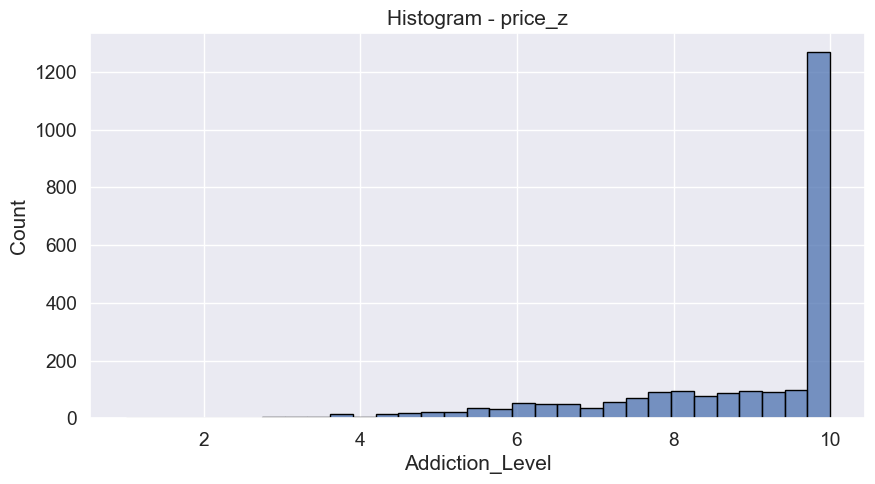

In [ ]:
# Visualize distribution of target variable
plt.figure(figsize=(10, 5))
sns.histplot(df_train.Addiction_Level, edgecolor="black", palette="viridis").set(title="Histogram - Addiction_Level")
plt.show()

In [20]:
#our plot is highly skewed and has outliers.
df_train['Addiction_Level'].skew()

np.float64(-1.5131638755763315)

Let's try log and square root transformations to improve normality

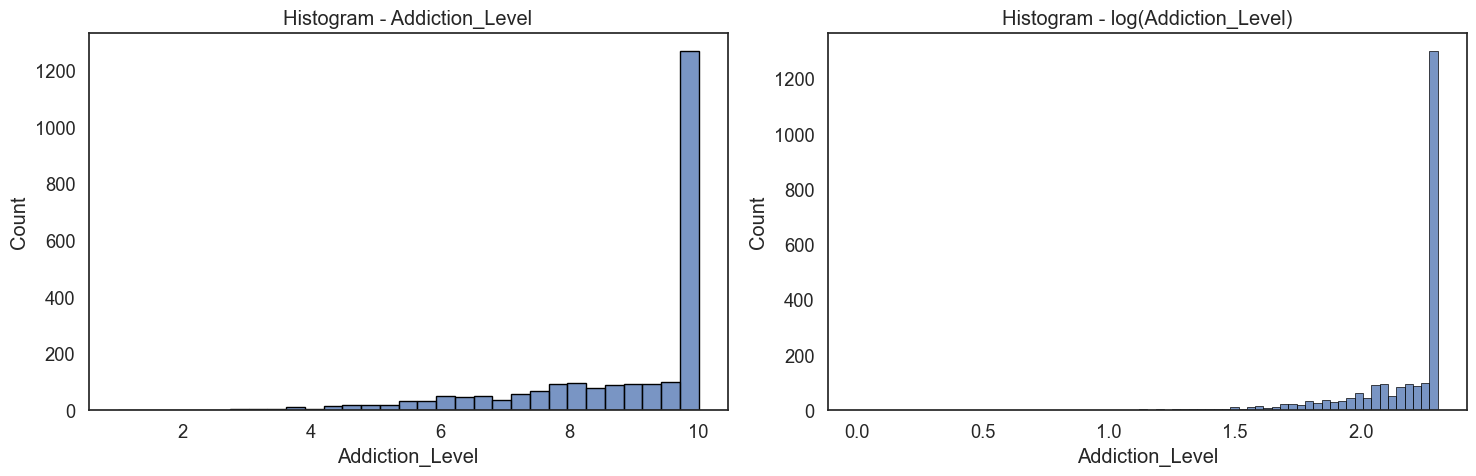

In [21]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(np.log(df_train["Addiction_Level"]), palette="viridis", edgecolor="black", ax=axes[1])
axes[1].set_title("Histogram - log(Addiction_Level)")
sns.histplot(df_train["Addiction_Level"], palette="viridis", edgecolor="black", ax=axes[0])
axes[0].set_title("Histogram - Addiction_Level")
plt.tight_layout()
plt.show()

Log scaling doesn't improve the distribution of target variable - let's try square root.

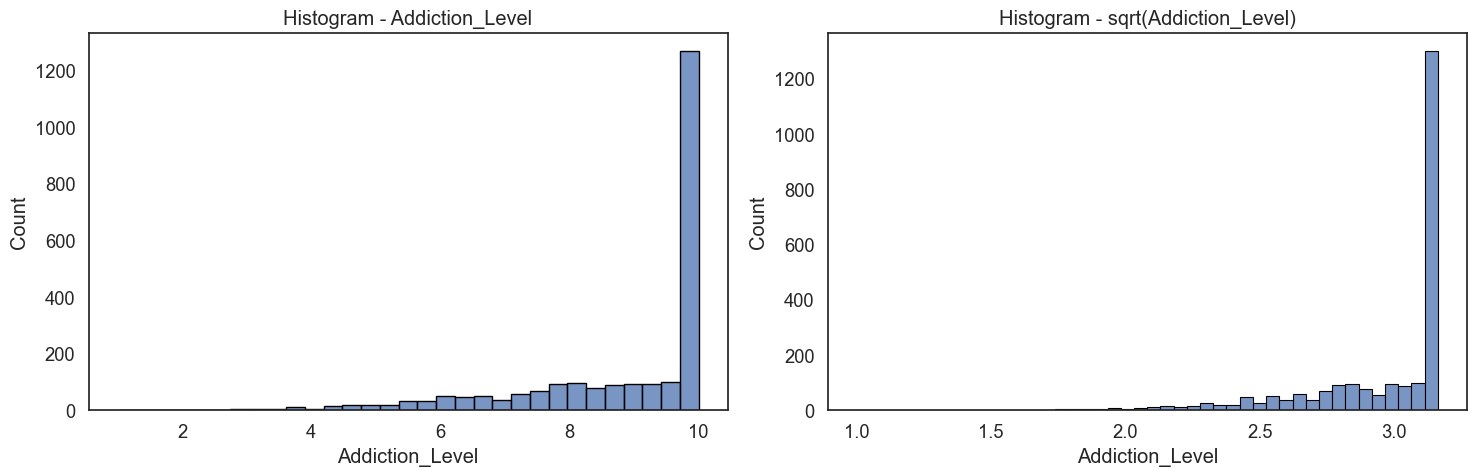

In [22]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(np.sqrt(df_train["Addiction_Level"]), palette="viridis", edgecolor="black", ax=axes[1])
axes[1].set_title("Histogram - sqrt(Addiction_Level)")
sns.histplot(df_train["Addiction_Level"], palette="viridis", edgecolor="black", ax=axes[0])
axes[0].set_title("Histogram - Addiction_Level")
plt.tight_layout()
plt.show()

In [23]:
df_train['Addiction_Level'].skew()

np.float64(-1.5131638755763315)

In [24]:
df_train['Addiction_Level'].kurtosis()

np.float64(1.78008747793838)

In [25]:
np.sqrt(df_train['Addiction_Level']).skew()

np.float64(-1.8829642064560914)

In [26]:
np.sqrt(df_train['Addiction_Level']).kurtosis()

np.float64(4.049109887283823)

In [27]:
np.log(df_train['Addiction_Level']).skew()

np.float64(-2.5697508355719423)

In [28]:
np.log(df_train['Addiction_Level']).kurtosis()

np.float64(10.155578760008245)

The target variable Addiction_Level will be modeled in its original scale. Applied transformations such as square root and logarithm increased skewness and kurtosis and even less normal distribution. Since most machine learning models do not require the target variable to follow a normal distribution, keeping the original form is the most appropriate choice.

### Statistical Analysis

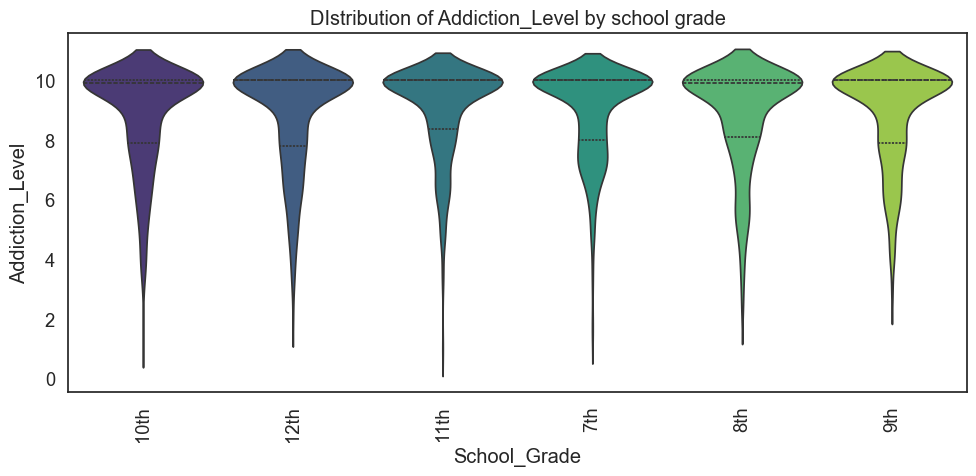

In [29]:
# Visualize addiction level distribution by school grade
plt.figure(figsize=(10, 5))
sns.violinplot(x=df_train["School_Grade"], y=df_train["Addiction_Level"], inner="quartile", palette="viridis")
plt.xticks(rotation=90)
plt.title("DIstribution of Addiction_Level by school grade")
plt.tight_layout()

In [30]:
# Statistical test: Does addiction differ by school grade?
# Using Kruskal-Wallis (non-parametric test, robust to non-normal distributions)

# Create groups of addiction levels for each school grade
groups = [df_train[df_train["School_Grade"] == g]["Addiction_Level"] for g in df_train["School_Grade"].unique()]

# Perform Kruskal-Wallis test
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis p-value = {p:.5f}")

Kruskal-Wallis p-value = 0.67286


To statistically verify the visual differences observed in the violin plot, we applied Kruskal–Wallis.
This non-parametric test was chosen due to the non-normal distribution of the target variable and the presence of multiple groups.
The results indicate that there is no significant difference between addiction level across school grades.

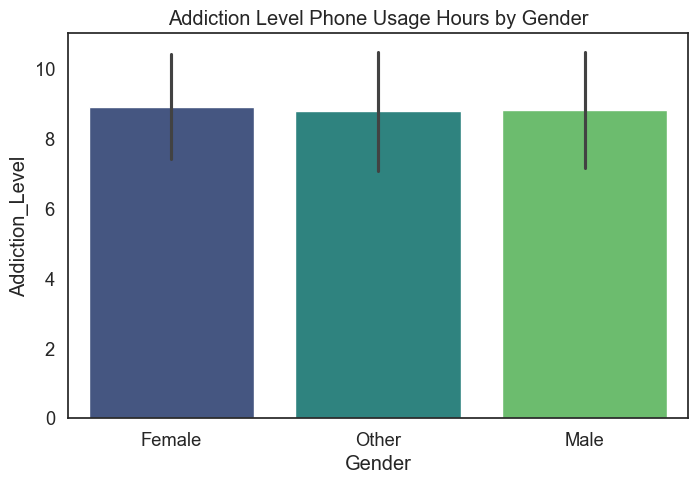

In [31]:
# Analyze addiction by gender
plt.figure(figsize=(8,5))
sns.barplot(data=df_train, x='Gender', y='Addiction_Level', ci='sd', palette='viridis')
plt.title('Addiction Level Phone Usage Hours by Gender')
plt.ylabel('Addiction_Level')
plt.xlabel('Gender')
plt.show()

Addiction level seems to be consistent across all genders - there are no significant differences based on the plot output.

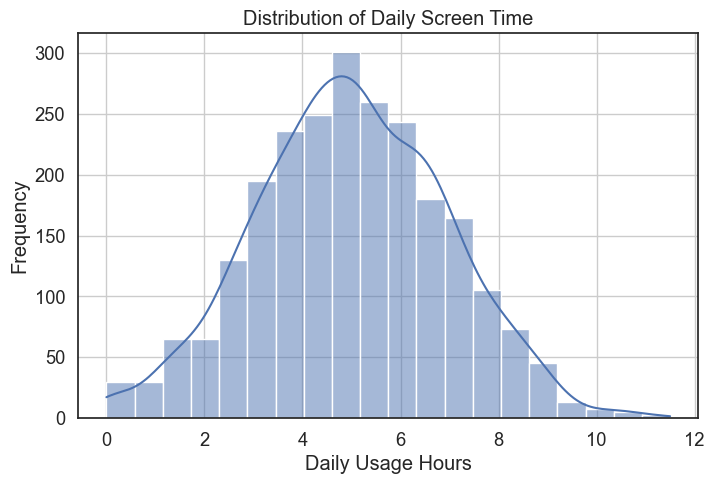

In [32]:
# Analyze daily usage hours distribution
plt.figure(figsize=(8,5))
sns.histplot(df_train['Daily_Usage_Hours'], kde=True, bins=20, palette='viridis')
plt.title('Distribution of Daily Screen Time')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The plot shows that most people spend around 4 to 6 hours per day using screens. The highest frequency is in this range, while very low and very high screen time values occur less often. Overall, daily screen time is concentrated around moderate usage levels, with only a few users spending more than 8 hours per day.

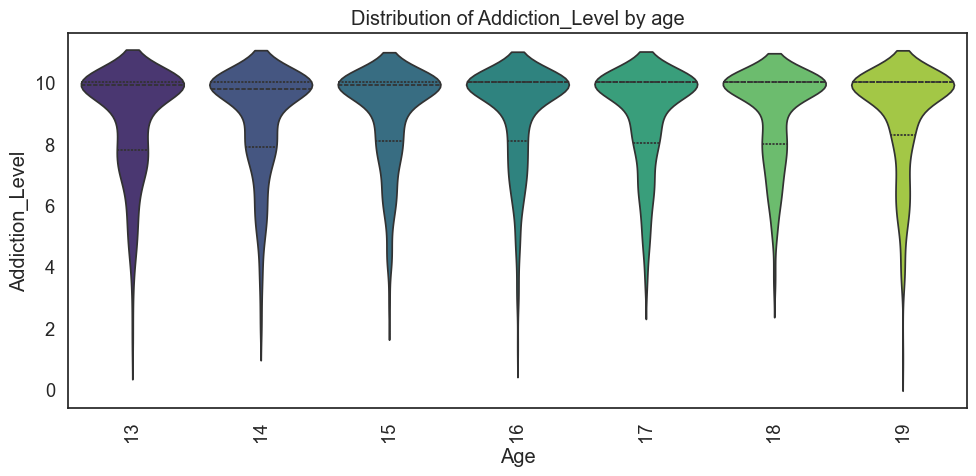

In [33]:
# Analyze addiction by age
plt.figure(figsize=(10, 5))
sns.violinplot(x=df_train["Age"], y=df_train["Addiction_Level"], inner="quartile", palette="viridis")
plt.xticks(rotation=90)
plt.title("Distribution of Addiction_Level by age")
plt.tight_layout()

Addiction level seems to be consistent across all age groups - there are no significant differences based on the plot output.

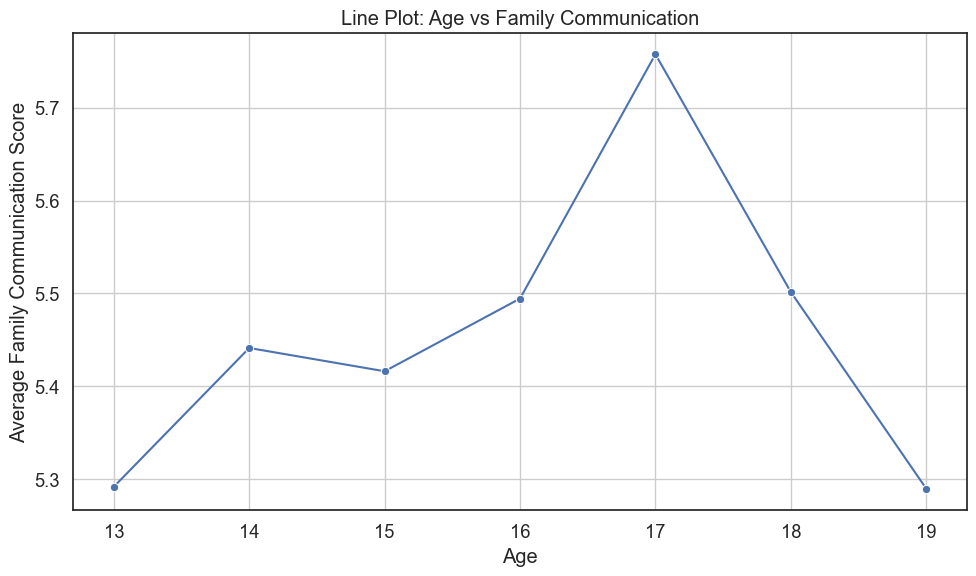

In [34]:
# Relationship: Age vs Family Communication
grouped_df = df_train.groupby('Age')['Family_Communication'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Age', y='Family_Communication', marker='o', palette='viridis')
plt.title('Line Plot: Age vs Family Communication')
plt.xlabel('Age')
plt.ylabel('Average Family Communication Score')
plt.grid(True)
plt.tight_layout()
plt.show()

The line plot shows how average family communication changes with age. The score increases slightly from age 13 to 16 and reaches its highest value at age 17. After that, it decreases for ages 18 and 19. Overall, family communication appears relatively stable across ages, with a small peak in mid-to-late adolescence.

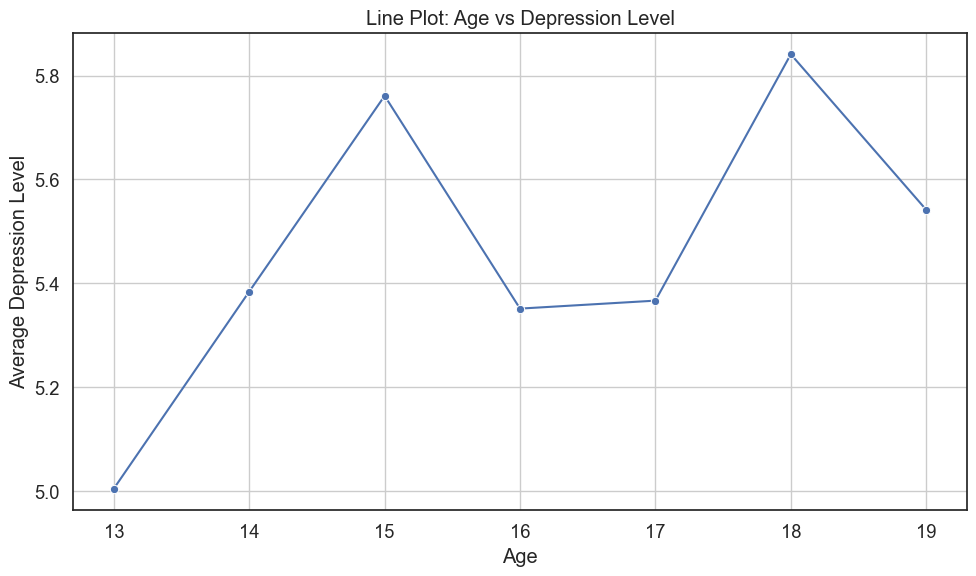

In [35]:
# Relationship: Age vs Depression Level
grouped_df = df.groupby('Age')['Depression_Level'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Age', y='Depression_Level', marker='o', palette='viridis')
plt.title('Line Plot: Age vs Depression Level')
plt.xlabel('Age')
plt.ylabel('Average Depression Level')
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the plot, depression levels appear to increase between ages 13 and 15, followed by a decline at age 16. Afterward, there is a rise in depression levels up to age 18, which then decreases at age 19


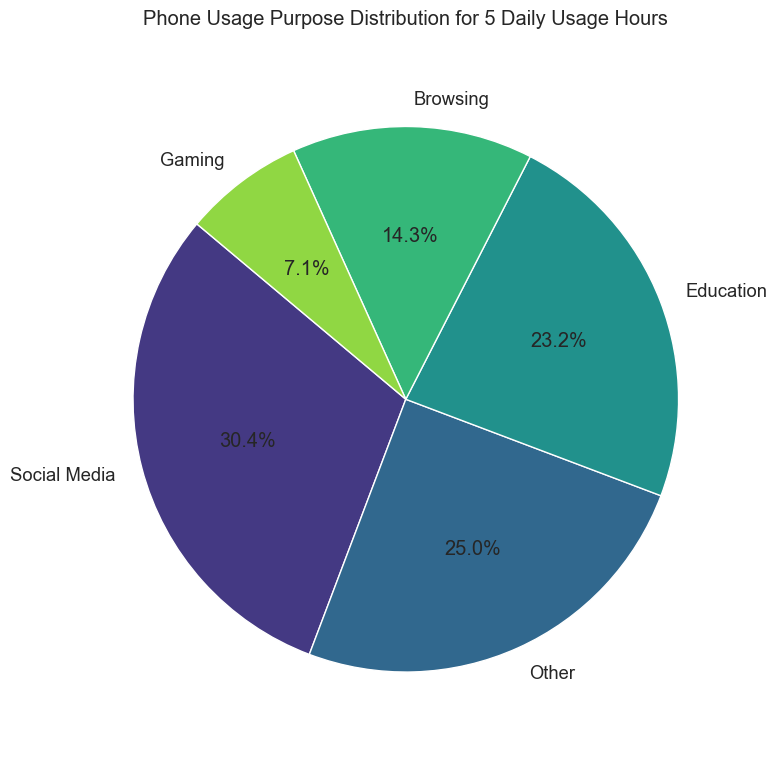

In [36]:
# Analyze daily usage purpose
usage_hour = 5
filtered_df = df_train[df_train['Daily_Usage_Hours'] == usage_hour]
purpose_counts = filtered_df['Phone_Usage_Purpose'].value_counts()

plt.figure(figsize=(8, 8))
colors = sns.color_palette("viridis", n_colors=len(purpose_counts))
plt.pie(purpose_counts, labels=purpose_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title(f'Phone Usage Purpose Distribution for {usage_hour} Daily Usage Hours')
plt.axis('equal')
plt.tight_layout()
plt.show()

The chart shows how students use their phones in a day, with 30.4% spent on social media, 25.0% on other activities, and 23.2% on education. Browsing takes up 14.3%, and gaming is the least at 7.1%. Social media is the most popular activity, followed by educational use.

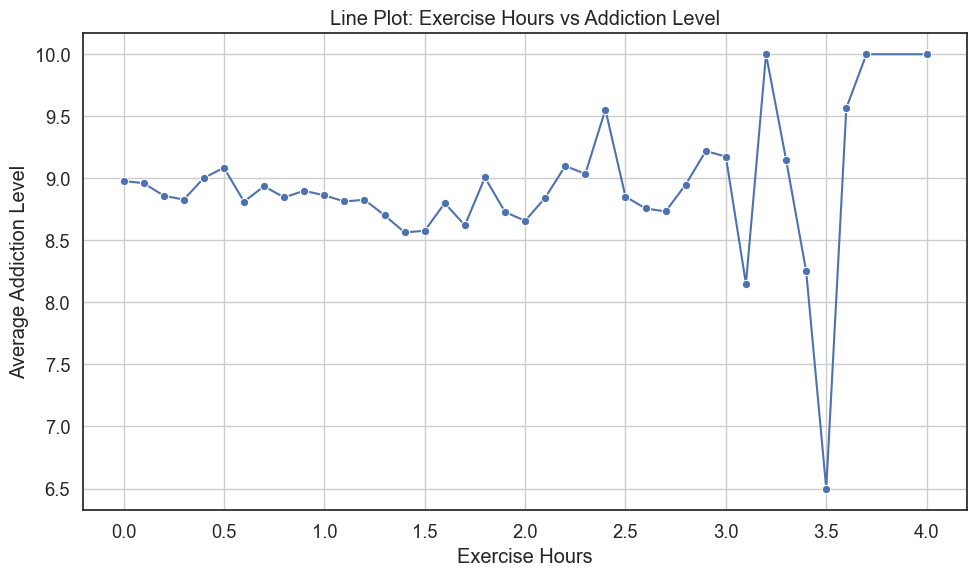

In [37]:
# Relationship: Exercise Hours vs Addiction Level
grouped_df = df_train.groupby('Exercise_Hours')['Addiction_Level'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Exercise_Hours', y='Addiction_Level', marker='o', palette='viridis')
plt.title('Line Plot: Exercise Hours vs Addiction Level')
plt.xlabel('Exercise Hours')
plt.ylabel('Average Addiction Level')
plt.grid(True)
plt.tight_layout()
plt.show()

The line graph shows the relationship between exercise hours and addiction level. When exercise hours are low, the addiction level stays high (around 9). As exercise hours increase, the addiction level generally goes down, showing that exercising more may help reduce addiction. However, the graph has a few sudden spikes and drops, which means the trend is not perfectly smooth.

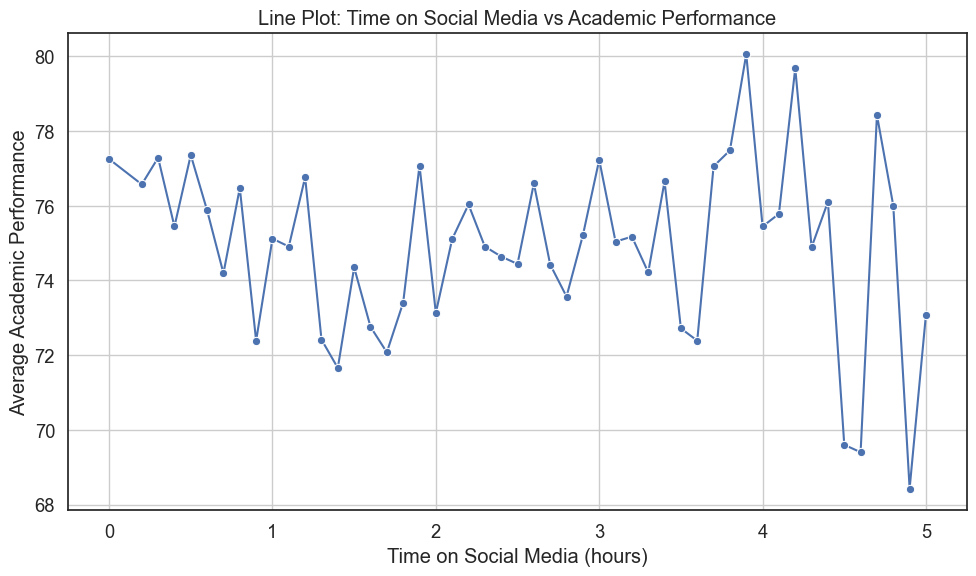

In [38]:
# Relationship: Time on Social Media vs Academic Performance
grouped_df = df_train.groupby('Time_on_Social_Media')['Academic_Performance'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Time_on_Social_Media', y='Academic_Performance', marker='o', palette='viridis')
plt.title('Line Plot: Time on Social Media vs Academic Performance')
plt.xlabel('Time on Social Media (hours)')
plt.ylabel('Average Academic Performance')
plt.grid(True)
plt.tight_layout()
plt.show()

This graph suggests that time on social media doesn’t have a clear or consistent impact on academic performance. The relationship seems to be more unpredictable, with academic performance fluctuating regardless of social media use.

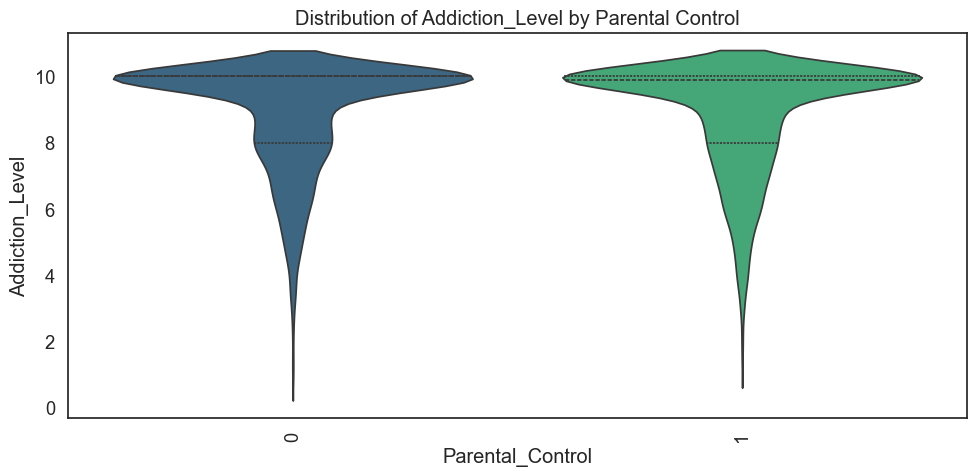

In [39]:
plt.figure(figsize=(10, 5))
sns.violinplot(x=df_train["Parental_Control"], y=df_train["Addiction_Level"], inner="quartile", palette="viridis")
plt.xticks(rotation=90)
plt.title("Distribution of Addiction_Level by Parental Control")
plt.tight_layout()

Addiction level seems to be consistent across both groups - there are no significant differences based on the plot output.

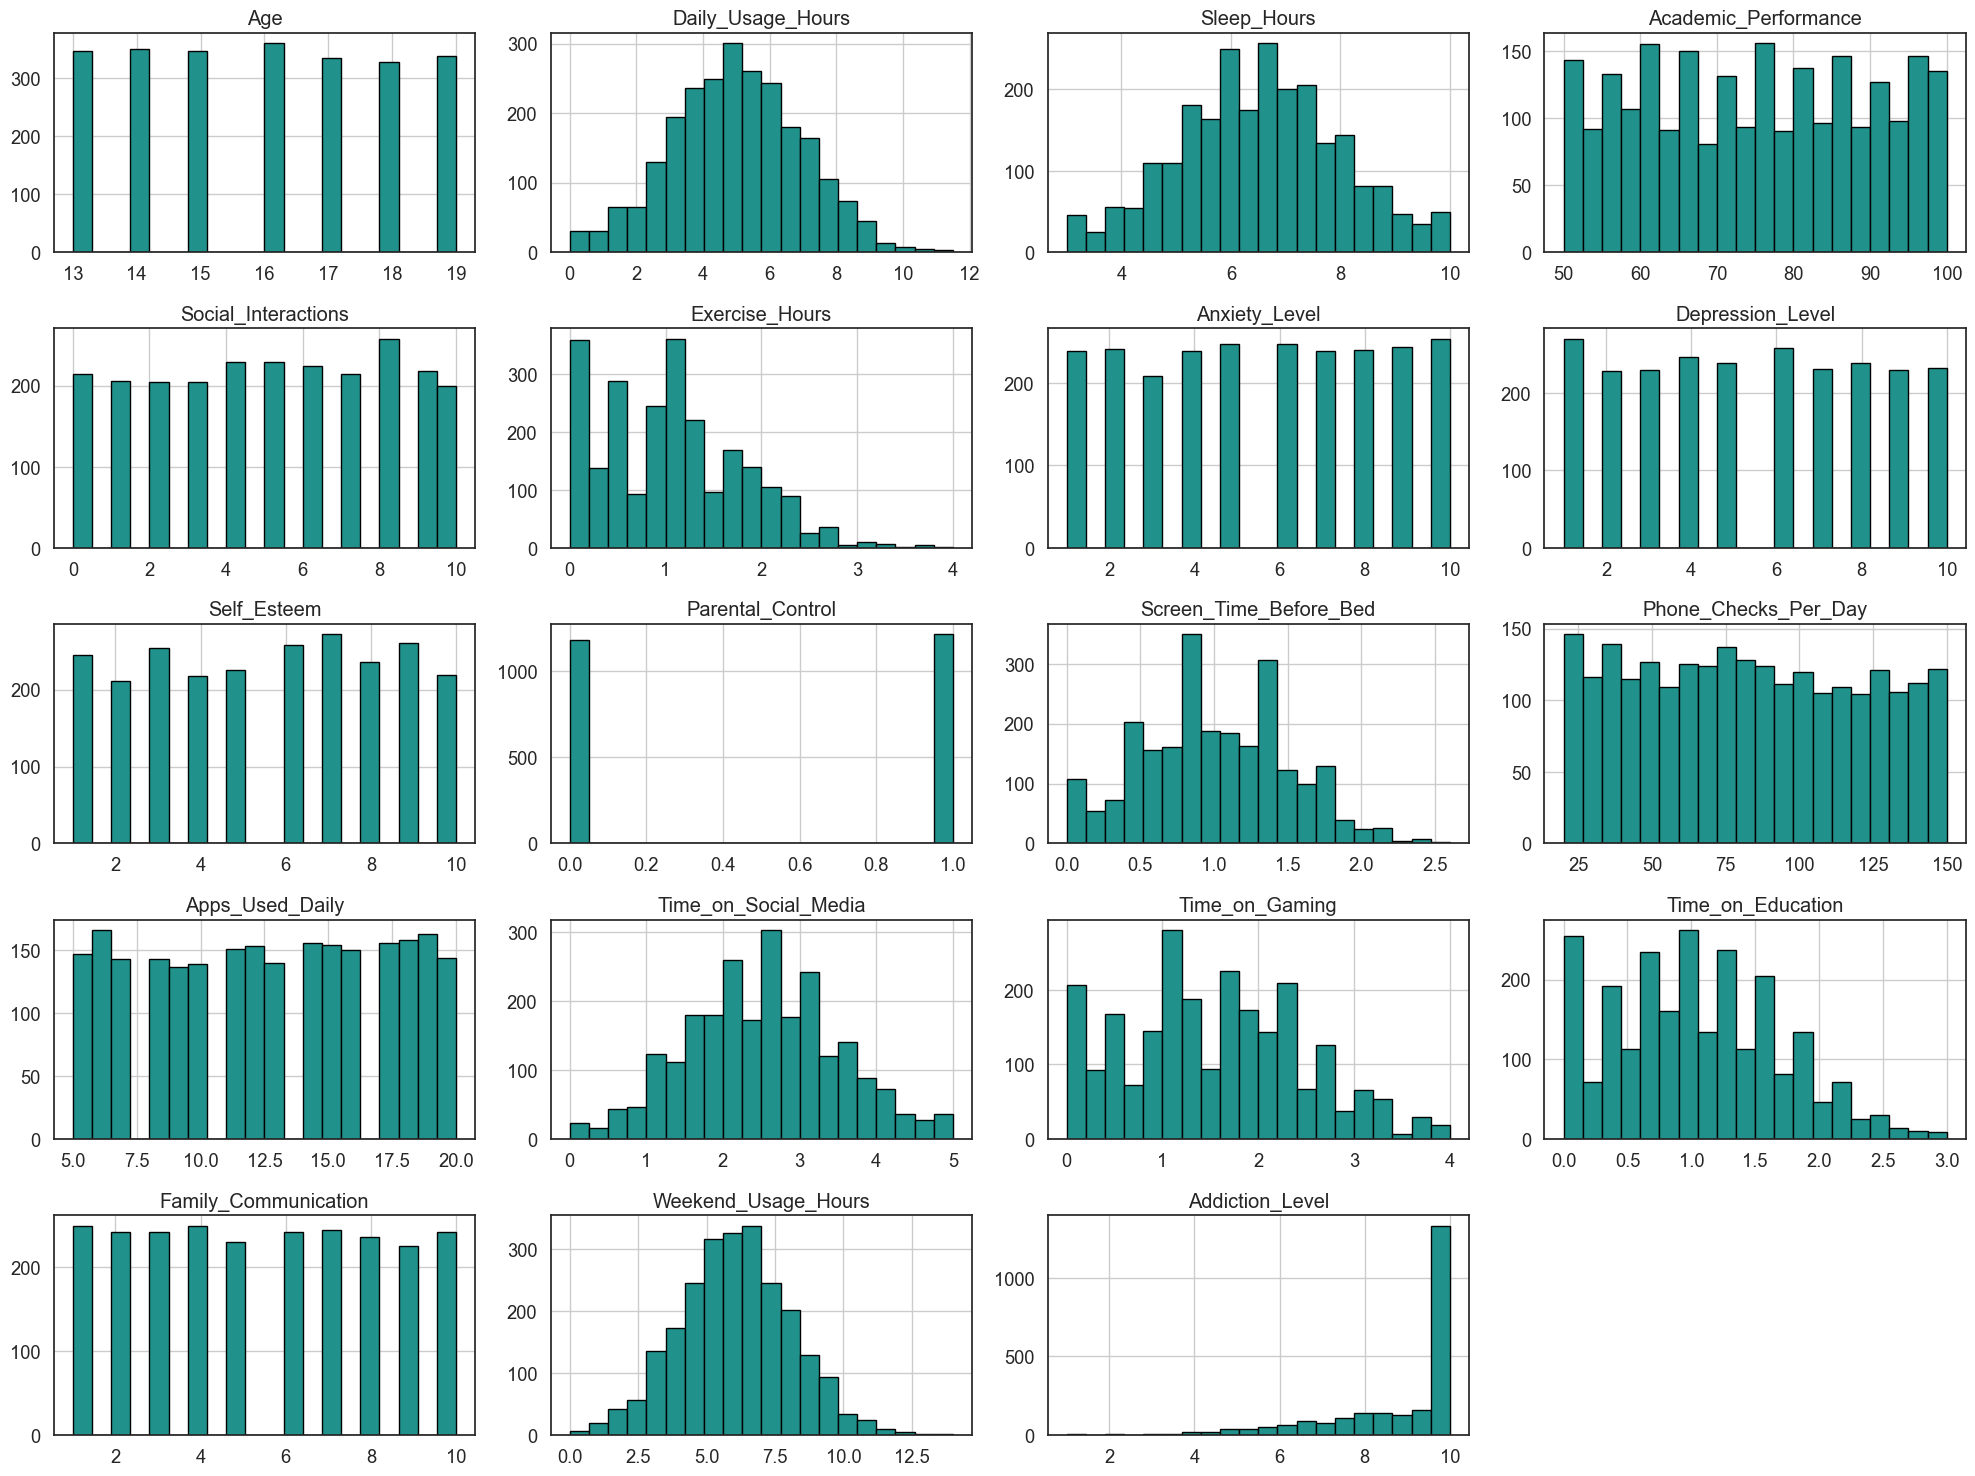

In [40]:
# Distribution of numeric features
num_df = df_train.select_dtypes(include=['float64', 'int64'])
colors = sns.color_palette("viridis", n_colors=1)
num_df.hist(
    bins=20,
    figsize=(20, 15),
    edgecolor='black',
    color=colors
)

plt.tight_layout()
plt.show()

# Section 4: Feature Engineering

We'll create derived features to capture behavioral patterns, reduce dimensionality, and improve model performance.

One-hot-encoding on Gender, School_Grade & Phone_Usage_Purpose

In [41]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 497 to 1346
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     2400 non-null   int64  
 1   Gender                  2400 non-null   object 
 2   School_Grade            2400 non-null   object 
 3   Daily_Usage_Hours       2400 non-null   float64
 4   Sleep_Hours             2400 non-null   float64
 5   Academic_Performance    2400 non-null   int64  
 6   Social_Interactions     2400 non-null   int64  
 7   Exercise_Hours          2400 non-null   float64
 8   Anxiety_Level           2400 non-null   int64  
 9   Depression_Level        2400 non-null   int64  
 10  Self_Esteem             2400 non-null   int64  
 11  Parental_Control        2400 non-null   int64  
 12  Screen_Time_Before_Bed  2400 non-null   float64
 13  Phone_Checks_Per_Day    2400 non-null   int64  
 14  Apps_Used_Daily         2400 non-null   int

In [42]:
df_train = pd.get_dummies(df_train, columns=["Gender"], drop_first=True)
df_train = pd.get_dummies(df_train, columns=["School_Grade"], drop_first=True)
df_train = pd.get_dummies(df_train, columns=["Phone_Usage_Purpose"], drop_first=True)

In [43]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 497 to 1346
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               2400 non-null   int64  
 1   Daily_Usage_Hours                 2400 non-null   float64
 2   Sleep_Hours                       2400 non-null   float64
 3   Academic_Performance              2400 non-null   int64  
 4   Social_Interactions               2400 non-null   int64  
 5   Exercise_Hours                    2400 non-null   float64
 6   Anxiety_Level                     2400 non-null   int64  
 7   Depression_Level                  2400 non-null   int64  
 8   Self_Esteem                       2400 non-null   int64  
 9   Parental_Control                  2400 non-null   int64  
 10  Screen_Time_Before_Bed            2400 non-null   float64
 11  Phone_Checks_Per_Day              2400 non-null   int64  
 12  Apps_Used

#### Additional features

We created dditional features to better capture behavioral patterns related to smartphone usage, including usage intensity, night-time activity, and lifestyle balance.

- Total_Phone_Time – total daily time spent on the phone, calculated as the sum of social media, gaming, and educational usage. It represents overall smartphone exposure.

- Checks_per_Hour – the number of phone checks normalized by daily usage hours, capturing compulsive checking behavior rather than long continuous sessions.

- Night_Usage_Ratio – the proportion of total phone usage that occurs before bedtime, reflecting potentially unhealthy night-time usage patterns.

- Digital_Life_Balance – a ratio combining sleep and physical activity relative to phone usage, indicating the balance between offline lifestyle and digital behavior.

- Entertainment_to_Education_Ratio – the relationship between entertainment-related phone use (social media and gaming) and educational use, distinguishing productive from leisure-oriented behavior.

- Exercise_Level – a categorical variable derived from weekly exercise hours, grouping physical activity into very low, low, moderate, and high levels to improve interpretability.

In [44]:
df_train["Total_Phone_Time"] = (df_train["Time_on_Social_Media"] + df_train["Time_on_Gaming"] + df_train["Time_on_Education"])

In [45]:
df_train["Checks_per_Hour"] = (df_train["Phone_Checks_Per_Day"] / (df_train["Daily_Usage_Hours"]+ 1e-12))

In [46]:
df_train["Night_Usage_Ratio"] = (df_train["Screen_Time_Before_Bed"] / (df_train["Daily_Usage_Hours"]+ 1e-12))

In [47]:
df_train["Digital_Life_Balance"] = (df_train["Exercise_Hours"] + df_train["Sleep_Hours"]) / (df_train["Daily_Usage_Hours"] + 1e-12)

In [48]:
df_train["Entertainment_to_Education_Ratio"] = ((df_train["Time_on_Social_Media"] + df_train["Time_on_Gaming"]) / (df_train["Time_on_Education"] + 1e-12))

In [49]:
df_train["Exercise_Level"] = pd.cut(df_train["Exercise_Hours"], bins=[-1, 1, 3, 6, 20], labels=["Very Low", "Low", "Moderate", "High"])
df_train = pd.get_dummies(df_train, columns=["Exercise_Level"], drop_first=True)

From Machine Learning 1 course we've taken code for downcasting our dataframe

The function downcast_dataframe() is used to reduce the memory usage of a DataFrame by converting each column to the smallest possible data type that can still hold all its values. Downcasting can reduce memory usage by 50–90%.

In [50]:
def downcast_dataframe(data):
    # Source: https://www.kaggle.com/anshuls235/time-series-forecasting-eda-fe-modelling
    df = data.copy()

    print("BEFORE downcast")
    print(df.info(memory_usage="deep"))
    print("=================")
    print("=================", "\n")

    cols = df.dtypes.index.tolist()
    types = df.dtypes.values.tolist()
    for i, t in enumerate(types):
        # Integer
        if "int" in str(t):
            # Check if minimum and maximum are in the limit of int8
            if (
                df[cols[i]].min() > np.iinfo(np.int8).min
                and df[cols[i]].max() < np.iinfo(np.int8).max
            ):
                df[cols[i]] = df[cols[i]].astype(np.int8)
            # Check if minimum and maximum are in the limit of int16
            elif (
                df[cols[i]].min() > np.iinfo(np.int16).min
                and df[cols[i]].max() < np.iinfo(np.int16).max
            ):
                df[cols[i]] = df[cols[i]].astype(np.int16)
            # Check if minimum and maximum are in the limit of int32
            elif (
                df[cols[i]].min() > np.iinfo(np.int32).min
                and df[cols[i]].max() < np.iinfo(np.int32).max
            ):
                df[cols[i]] = df[cols[i]].astype(np.int32)
            # Choose int64
            else:
                df[cols[i]] = df[cols[i]].astype(np.int64)
        # Float
        elif "float" in str(t):
            if (
                df[cols[i]].min() > np.finfo(np.float32).min
                and df[cols[i]].max() < np.finfo(np.float32).max
            ):
                df[cols[i]] = df[cols[i]].astype(np.float32)
            else:
                df[cols[i]] = df[cols[i]].astype(np.float64)
        # Object
        elif t == object:
            if cols[i] == "date":
                df[cols[i]] = pd.to_datetime(df[cols[i]], format="%Y-%m-%d")
            else:
                df[cols[i]] = df[cols[i]].astype("category")
    print("AFTER downcast")
    print(df.info(memory_usage="deep"))
    return df

In [51]:
df_train = downcast_dataframe(df_train)

BEFORE downcast
<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 497 to 1346
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               2400 non-null   int64  
 1   Daily_Usage_Hours                 2400 non-null   float64
 2   Sleep_Hours                       2400 non-null   float64
 3   Academic_Performance              2400 non-null   int64  
 4   Social_Interactions               2400 non-null   int64  
 5   Exercise_Hours                    2400 non-null   float64
 6   Anxiety_Level                     2400 non-null   int64  
 7   Depression_Level                  2400 non-null   int64  
 8   Self_Esteem                       2400 non-null   int64  
 9   Parental_Control                  2400 non-null   int64  
 10  Screen_Time_Before_Bed            2400 non-null   float64
 11  Phone_Checks_Per_Day              2400 non-null   int64 

In [52]:
# Apply same transformations to test set
df_test = df_test.drop(columns=["Location"])
df_test = pd.get_dummies(df_test, columns=["Gender"], drop_first=True)
df_test = pd.get_dummies(df_test, columns=["School_Grade"], drop_first=True)
df_test = pd.get_dummies(df_test, columns=["Phone_Usage_Purpose"], drop_first=True)

df_test["Total_Phone_Time"] = (df_test["Time_on_Social_Media"] + df_test["Time_on_Gaming"] + df_test["Time_on_Education"])
df_test["Checks_per_Hour"] = (df_test["Phone_Checks_Per_Day"] / (df_test["Daily_Usage_Hours"]+1e-12))
df_test["Night_Usage_Ratio"] = (df_test["Screen_Time_Before_Bed"] / (df_test["Daily_Usage_Hours"]+1e-12))
df_test["Digital_Life_Balance"] = (df_test["Exercise_Hours"] + df_test["Sleep_Hours"]) / (df_test["Daily_Usage_Hours"]+1e-12)
df_test["Entertainment_to_Education_Ratio"] = ((df_test["Time_on_Social_Media"] + df_test["Time_on_Gaming"]) / (df_test["Time_on_Education"] + 1e-3))
df_test["Exercise_Level"] = pd.cut(df_test["Exercise_Hours"], bins=[-1, 1, 3, 6, 20], labels=["Very Low", "Low", "Moderate", "High"])
df_test = pd.get_dummies(df_test, columns=["Exercise_Level"], drop_first=True)

In [53]:
df_test = downcast_dataframe(df_test)

BEFORE downcast
<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 1690 to 447
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               600 non-null    int64  
 1   Daily_Usage_Hours                 600 non-null    float64
 2   Sleep_Hours                       600 non-null    float64
 3   Academic_Performance              600 non-null    int64  
 4   Social_Interactions               600 non-null    int64  
 5   Exercise_Hours                    600 non-null    float64
 6   Anxiety_Level                     600 non-null    int64  
 7   Depression_Level                  600 non-null    int64  
 8   Self_Esteem                       600 non-null    int64  
 9   Parental_Control                  600 non-null    int64  
 10  Screen_Time_Before_Bed            600 non-null    float64
 11  Phone_Checks_Per_Day              600 non-null    int64  

In [54]:
# Verify column alignment between train and test sets
set(df_train.columns) - set(df_test.columns)

set()

In [55]:
set(df_test.columns) - set(df_train.columns)

set()

In [56]:
df_train.columns

Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level',
       'Gender_Male', 'Gender_Other', 'School_Grade_11th', 'School_Grade_12th',
       'School_Grade_7th', 'School_Grade_8th', 'School_Grade_9th',
       'Phone_Usage_Purpose_Education', 'Phone_Usage_Purpose_Gaming',
       'Phone_Usage_Purpose_Other', 'Phone_Usage_Purpose_Social Media',
       'Total_Phone_Time', 'Checks_per_Hour', 'Night_Usage_Ratio',
       'Digital_Life_Balance', 'Entertainment_to_Education_Ratio',
       'Exercise_Level_Low', 'Exercise_Level_Moderate', 'Exercise_Level_High'],
      dtype='object')

# Section 5: Model Training with Decision Tree Regressor

We'll build a Decision Tree Regressor with hyperparameter tuning using GridSearchCV and 5-fold cross-validation.

Reason for choosing this model for our problem:

- Baseline model - Trees are interpretable and capture non-linear relationships without requiring feature scaling
- Feature importance - Directly reveals which variables matter most for predicting addiction
- No assumptions - Unlike linear models, doesn't assume linear relationships between predictors and addiction level

## Step 1: Prepare training and test data

In [57]:
# Prepare training and test data
# Separate features (X) from target (y) for both training and test sets
X_train = df_train.drop(columns=["Addiction_Level"])
y_train = df_train["Addiction_Level"]

X_test = df_test.drop(columns=["Addiction_Level"])
y_test = df_test["Addiction_Level"]



# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Create preprocessing pipeline
# StandardScaler: Normalize features to have mean=0 and std=1
# (Not strictly necessary for trees, but keeps pipeline consistent)
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        # scaling not required for trees, but harmless; keeps pipeline consistent
        ("num", StandardScaler(with_mean=False), numeric_features)
    ],
    remainder="drop"
)

# Build and tune Decision Tree Regressor
pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Define hyperparameter grid for tree tuning
# max_depth: Maximum tree depth (prevents overfitting)
# min_samples_leaf: Minimum samples required at leaf node
# min_samples_split: Minimum samples required to split node
param_grid = {
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

# Extract best model from grid search
best_dt = grid.best_estimator_
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

# Evaluate best model on hold-out test set
y_pred = best_dt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nHold-out test results (Decision Tree):")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

Best CV MAE: 0.5225696291040886
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Hold-out test results (Decision Tree):
MAE  = 0.462
RMSE = 0.762
R²   = 0.748


The Decision Tree achieved strong predictive performance with an R² of 0.748, meaning it explains 74.8% of the variance in addiction levels. On average, predictions deviate by 0.462 points (MAE) from actual addiction scores.

# Section 6: Model Training with Random Forest Regressor

Random Forest builds multiple decision trees and averages predictions for better generalization.

Reason for choosing this model for our problem: 
- Reduces overfitting - Multiple trees with bootstrapped samples and feature randomness create robust predictions
- Feature importance ranking - Aggregates importance across all trees, giving reliable feature rankings
- Robust to outliers - our target variable distribution has skewness and outliers and Random Forest is less sensitive for them

In [58]:
# Create pipeline with Random Forest
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Define hyperparameter grid for Random Forest
# n_estimators: Number of trees in the forest
# max_depth: Maximum depth of each tree
# max_features: Number of features to consider at each split
# min_samples_leaf: Minimum samples at leaf node
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 15],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", 0.5]
}

# Perform GridSearchCV for Random Forest
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

# Extract best model
best_rf = grid.best_estimator_
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

# Evaluate best model on hold-out test set
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nHold-out test results (Random Forest):")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

Best CV MAE: 0.3766980229102075
Best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}

Hold-out test results (Random Forest):
MAE  = 0.349
RMSE = 0.502
R²   = 0.891


The Random Forest model significantly outperforms the Decision Tree, achieving an R² of 0.891 (explaining 89.1% of variance in addiction levels) with a lower MAE of 0.349, demonstrating that ensemble methods with multiple trees and bootstrap sampling effectively reduce overfitting and capture complex behavioral patterns in smartphone addiction prediction.

# Section 7: Model Training with AdaBoost Regressor

AdaBoost builds an ensemble of weak learners, focusing on instances that previous models found difficult.

Reason for choosing this model for our problem:
- Sequential learning - Focuses on instances the previous model misclassified, reducing bias and variance
- Handles difficult cases - Emphasizes harder-to-predict addiction levels, improving overall performance
- Adaptive weighting - Learns which samples are most informative for addiction prediction task
- Prevents underfitting - Particularly useful when simpler models underfit complex behavioral patterns

In [59]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features)
    ],
    remainder="drop"
)

# Base estimator (weak learner)
base_tree = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

# Create pipeline with AdaBoost
pipe = Pipeline([
    ("prep", preprocess),
    ("model", AdaBoostRegressor(
        estimator=base_tree,
        random_state=42
    ))
])

# Define hyperparameter grid for AdaBoost
# n_estimators: Number of boosting stages
# learning_rate: Shrinks contribution of each boosting stage
# loss: Loss function (linear, square, or exponential)
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
    "model__loss": ["linear", "square", "exponential"]
}

# Perform GridSearchCV for AdaBoost
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

best_ada = grid.best_estimator_
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

# Evaluate best model on hold-out test set
y_pred = best_ada.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nHold-out test results (AdaBoost):")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

Best CV MAE: 0.824513037766547
Best params: {'model__learning_rate': 0.05, 'model__loss': 'exponential', 'model__n_estimators': 100}

Hold-out test results (AdaBoost):
MAE  = 0.811
RMSE = 1.003
R²   = 0.564


The AdaBoost model underperforms compared to both Decision Tree and Random Forest, achieving an R² of 0.564 (explaining only 56.4% of variance) with a MAE of 0.811. This suggests that AdaBoost's sequential boosting approach with shallow weak learners struggles to capture the complex non-linear patterns in addiction prediction,